# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Eric Lopes, Guilherme Braga, Guilherme Saggion

**RA**: 822873, 823161, 823159


---
## Análise exploratória

Nesta seção, deve ser feita a leitura da base de dados e todas as análises necessárias para interpretar e analisar os dados, tais como:
* Significado de cada atributo
* Medidas descritivas
* Gráficos

In [ ]:
# Instalação automatizada das dependências para evitar quebras de execução
!pip install spacy simplemma scikit-learn pandas numpy gensim
!pip install --quiet transformers datasets peft accelerate sentencepiece
!pip install --quiet pandas numpy matplotlib seaborn nltk gensim scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Importação de bibliotecas e inicialização de parâmetros

In [ ]:
import os
import sys
import builtins
import matplotlib.pyplot as plt
import seaborn as sns

caminho_kaggle = '/kaggle/input/datasets/guilhermesaggion2003/projetopln/ProjetoPLN/implementacao'

if os.path.exists(caminho_kaggle):
    os.chdir(caminho_kaggle)
    print("Ambiente: Kaggle detectado. Diretório de trabalho alterado.")
    
    # Cria as pastas necessárias na área de escrita permitida
    os.makedirs('/kaggle/working/figs', exist_ok=True)
    os.makedirs('/kaggle/working/dados/representacoes', exist_ok=True)
    
    _original_savefig = plt.savefig
    def _patched_savefig(fname, *args, **kwargs):
        fname_str = str(fname)
        if fname_str.startswith('figs/'):
            fname = os.path.join('/kaggle/working', fname_str)
        return _original_savefig(fname, *args, **kwargs)
    plt.savefig = _patched_savefig

    _original_makedirs = os.makedirs
    def _patched_makedirs(name, *args, **kwargs):
        name_str = str(name)
        if ('dados' in name_str or 'figs' in name_str) and not name_str.startswith('/kaggle'):
            name = os.path.join('/kaggle/working', name_str.replace('../', '').replace('./', ''))
        return _original_makedirs(name, *args, **kwargs)
    os.makedirs = _patched_makedirs

    _original_open = builtins.open
    def _patched_open(file, mode='r', *args, **kwargs):
        file_str = str(file)
        if any(m in mode for m in ['w', 'a', 'x', '+']) and not file_str.startswith('/kaggle'):
            if 'dados' in file_str or 'figs' in file_str or 'modelos' in file_str:
                limpo = file_str.replace('../', '').replace('./', '')
                file = os.path.join('/kaggle/working', limpo)
                _original_makedirs(os.path.dirname(file), exist_ok=True)
        return _original_open(file, mode, *args, **kwargs)
    builtins.open = _patched_open

else:
    print("Ambiente: Local detectado. Estrutura padrão mantida.")

sys.path.append(os.getcwd())


from scripts import analise_exploratoria as ae

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("\n[OK] Ambiente pronto e configurado com sucesso.")

Ambiente: Local (Seu PC) detectado. Estrutura padrão mantida.

[OK] Ambiente pronto e configurado com sucesso.


### 2. Carregamento dos dados

In [5]:
train_df, test_df, sample_submission = ae.carregar_dados(
    '../dados/train.csv', '../dados/test.csv', '../dados/sample_submission.csv'
)
train_valid = ae.filtrar_categorias_validas(train_df)

Treinamento : (22680, 3)
Teste       : (2521, 2)
Submissão   : (15, 2)


### 3. Estrutura e tipos dos dados

| Atributo   | Tipo   | Descrição |
|------------|--------|-----------|
| `Id`       | int64  | Identificador único do documento |
| `Body`     | object | Texto extraído de uma página do documento (via OCR) |
| `Category` | int64  | Classe: 0=Acórdão, 1=ARE, 2=Despacho, 3=RE, 4=Sentença |

In [6]:
ae.exibir_estrutura(train_df, test_df)

=== Primeiras linhas — treino ===


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3



=== Informações gerais — treino ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22680 entries, 0 to 22679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        22680 non-null  int64 
 1   Body      22680 non-null  object
 2   Category  22680 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 531.7+ KB

=== Primeiras linhas — teste ===


,Id,Body
0,9213,"{""um regime democrática direito qual seja da s..."
1,17427,"{""controvérsia fato que requerente participant..."
2,4753,"{""advocacia geral união procuradoria união par..."
3,4640,"{""advocacia geral união procuradoria união est..."
4,20412,"{""ministério fazenda procuradoria geral fazend..."


##### 1. Estrutura dos Dados
* Id: Identificador numérico único.

* Body: Texto bruto do documento jurídico.

* Category: Variável alvo numérica (classes 1 e 3 observadas na amostra).

##### 2. Anomalias Identificadas (Body)
* Erro de Codificação (Encoding): Caracteres acentuados distorcidos (ex: conclusÃ£o, uniÃ£o). 

* Ruídos de Formatação: Presença do prefixo {" nas strings. Indica resquícios de estrutura JSON ou dicionário.

* Características Textuais: Conteúdo predominantemente em letras minúsculas e sem pontuação regular, assemelhando-se a uma estrutura bag of words.

##### 3. Insights para o Pré-processamento
* Ajustar o encoding na leitura do CSV.

* Desenvolver função para remoção de artefatos como {" e limpeza de caracteres especiais.

* Aplicar o pipeline de PLN obrigatório: remoção de stop words, tokenização e lematização.

### 4. Qualidade dos dados (ausentes e duplicatas)

In [7]:
ae.verificar_qualidade(train_df, test_df)

=== Valores ausentes — treino ===
Id          0
Body        0
Category    0
dtype: int64

=== Valores ausentes — teste ===
Id      0
Body    0
dtype: int64

Body duplicado no treino : 11183
Body duplicado no teste  : 566

=== Categorias no treino ===
Category
-1     2268
 0      665
 1     3529
 2      439
 3    12876
 4     2903
Name: count, dtype: int64


#### Integridade, Duplicatas e Distribuição

##### 1. Qualidade dos Dados (Valores Ausentes)

- Não há valores ausentes (NaN) nas colunas de treino ou teste. Os dados estão estruturalmente completos.

##### 2. Anomalias Identificadas (Duplicatas e Classes)

- Volume Crítico de Duplicatas: Há um número alarmante de textos repetidos no Body. No treino, 11.183 textos são duplicados (praticamente 50% da base). No teste, são 566 textos repetidos. Em contextos jurídicos, isso geralmente indica documentos padronizados ("boilerplate") ou despachos em massa.

- A classe -1 possui 2.268 registros no treino. No entanto, o escopo do projeto prevê apenas cinco classes oficiais (0 a 4). Essa categoria representa ruído ou documentos não rotulados.

- Desbalanceamento Severo: A classe 3 (Recurso Extraordinário) é amplamente majoritária (12.876 amostras), enquanto as classes 2 (Despacho) e 0 (Acórdão) possuem menos de 700 amostras cada.

##### 3. Insights para o Pré-processamento

1. Tratamento da Categoria -1: Excluir os registros com a classe -1 do conjunto de treinamento, pois eles não são alvo da classificação do projeto e prejudicarão o aprendizado do modelo.

2. Gestão de Duplicatas: Avaliar a remoção das duplicatas exatas apenas no conjunto de treinamento:
   ```python
   train.drop_duplicates(subset=['Body'])
   ```
   Manter cópias idênticas no treino pode causar superajuste (*overfitting*).

3. Balanceamento: Devido à discrepância entre as classes, será obrigatório o uso de técnicas para minimizar ou acabar com o desbalanceamento durante o treinamento (ex: class_weight='balanced') e avaliar os modelos focando na métrica F1-Score.

### 5. Distribuição das classes


=== Distribuição das classes ===


,Contagem,Percentual (%)
Category_name,,
Desconhecido,2268,10.00
Acórdão,665,2.93
ARE,3529,15.56
Despacho,439,1.94
RE,12876,56.77
Sentença,2903,12.80


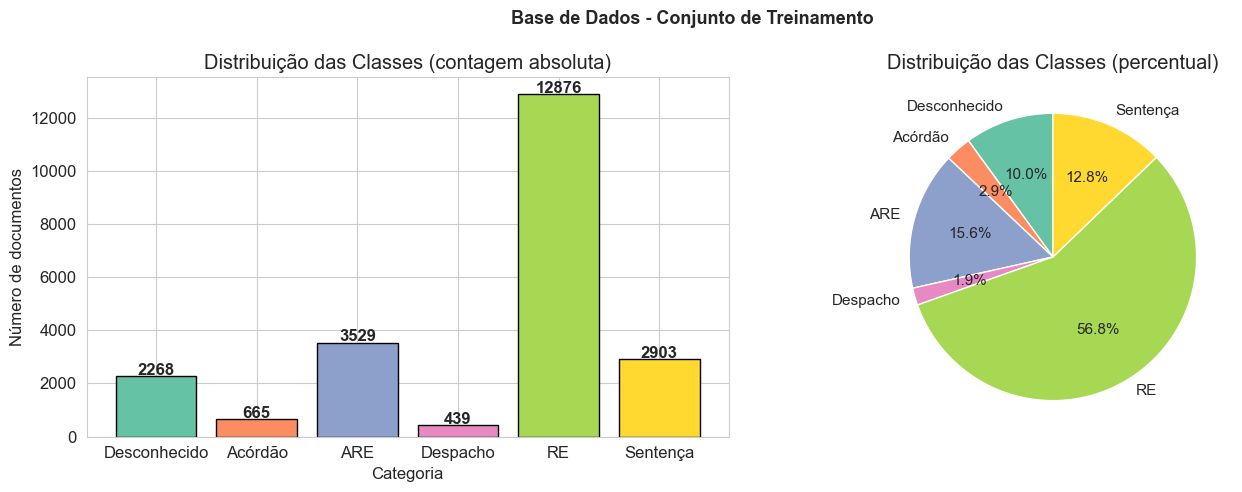


Total de amostras válidas: 22,680
Razão desbalanceamento (maior/menor): 29.33x


In [ ]:
import os

# Define a pasta de escrita do Kaggle para salvar a imagem
pasta_saida = '/kaggle/working/figs'
os.makedirs(pasta_saida, exist_ok=True)

caminho_grafico = os.path.join(pasta_saida, 'distribuicao_classes.png')

class_counts, class_pct = ae.plotar_distribuicao_classes(
    train_valid, 
    save_path=caminho_grafico
)

##### 1. Distribuição de Classes

- Desbalanceamento Extremo: O gráfico confirma visualmente o severo desbalanceamento de classes que foi notado na análise dos dados textuais. A categoria 3 (Recurso Extraordinário) domina massivamente o conjunto de dados, com um volume de amostras muito superior a todas as outras categorias combinadas.

- Classes Minoritárias: As categorias 0 (Acórdão) e 2 (Despacho) são as classes minoritárias, apresentando uma contagem de amostras significativamente baixa.

##### 2. Insights para o Pré-processamento

2. Estratégias de Balanceamento: A predominância da classe 3 e a escassez das classes 0 e 2 tornam o emprego de técnicas de balanceamento uma etapa crítica. Sem esse tratamento, o modelo tenderá a prever a classe 3 majoritariamente, ignorando as classes com menor representatividade. Serão consideradas as seguintes técnicas:

   - Ajuste de Pesos: Penalizar erros nas classes minoritárias durante o treinamento.
   - Sobreamostragem: Aumentar sinteticamente o número de amostras das classes minoritárias (ex: SMOTE).
   - Subamostragem: Reduzir o número de amostras da classe majoritária — menos recomendado se a base for pequena, mas viável dada a quantidade da classe 3.

3. Avaliação: Devido ao desbalanceamento, a acurácia não será uma métrica confiável. O projeto exige foco em métricas robustas ao desbalanceamento. O F1-Score será fundamental para avaliar se o modelo está realmente aprendendo a classificar as classes minoritárias.

### 6. Comprimento dos textos

=== Estatísticas de comprimento dos textos ===


,num_chars,num_words,num_sentences
count,22680.0,22680.0,22680.0
mean,1758.2,216.4,0.0
std,750.1,93.1,0.0
min,4.0,1.0,0.0
25%,1293.0,159.0,0.0
50%,1715.0,209.0,0.0
75%,2177.0,268.0,0.0
max,6867.0,844.0,0.0


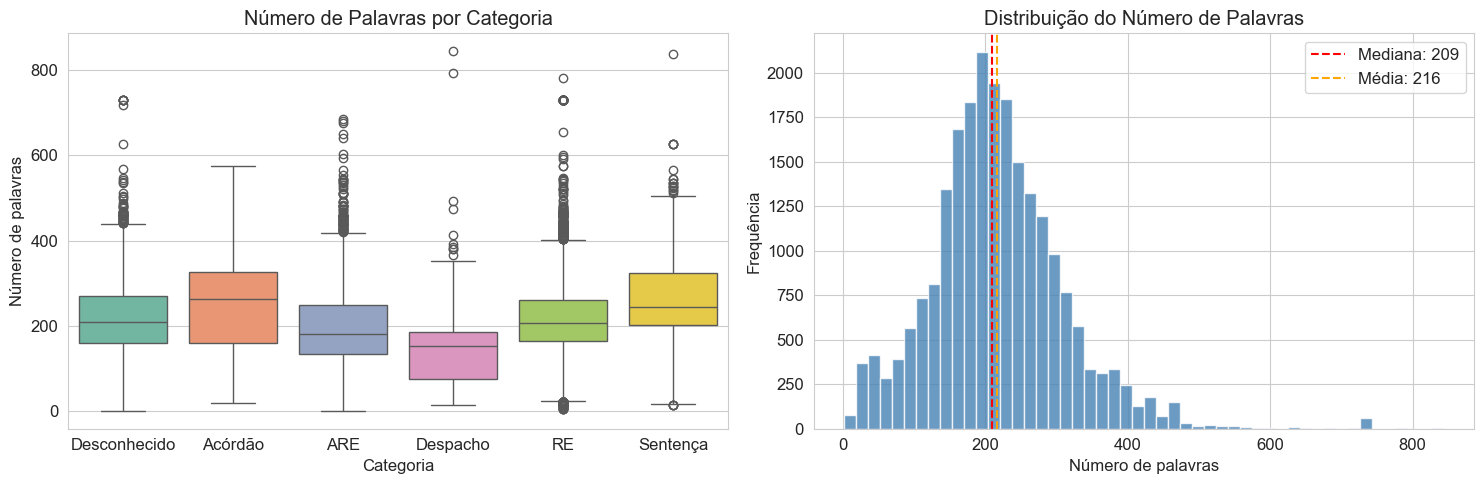


=== Média de palavras por categoria ===


,num_chars,num_words,num_sentences
Category_name,,,
Desconhecido,1769.6,218.0,0.0
Acórdão,2011.9,251.5,0.0
ARE,1578.1,195.2,0.0
Despacho,1195.7,149.0,0.0
RE,1746.6,213.9,0.0
Sentença,2047.0,254.4,0.0


In [9]:
train_valid = ae.adicionar_metricas_comprimento(train_valid)
ae.plotar_comprimento_textos(train_valid)

#### Análise Exploratória: Estatísticas de Comprimento dos Textos

##### 1. Visão Geral da Distribuição

- Variação de Tamanho: Os documentos possuem, em média, 216 palavras (cerca de 1.757 caracteres). No entanto, o desvio padrão de 92,8 palavras indica uma dispersão considerável.

- Valores Atípicos (Outliers): O valor mínimo aponta para textos com apenas 1 palavra (4 caracteres), o que provavelmente representa ruído de extração (OCR) ou falhas de formatação. O valor máximo atinge 844 palavras.

##### 2. Anomalias Identificadas

- Ausência de Sentenças: A métrica num_sentences está em 0.0 para todas as faixas e categorias. Isso comprova de forma definitiva a observação anterior de que o texto não possui pontuação regular (pontos finais, exclamações, etc.), comportando-se como uma bag of words.

##### 3. Diferenças por Categoria

- Padrões de Extensão: O tamanho do texto varia de acordo com o tipo de documento. "Sentença" (média de 254 palavras) e "Acórdão" (251 palavras) são os documentos mais extensos.

- Textos Curtos: A categoria "Despacho" é significativamente mais curta, com média de apenas 149 palavras, o que faz sentido do ponto de vista jurídico (costumam ser decisões rápidas de andamento processual).

##### 4. Recomendações para Modelagem

1. Filtro de Ruído: Deve ser avaliado a exclusão de registros excessivamente curtos, pois não contêm contexto jurídico suficiente para classificação.

2. Engenharia de Atributos: O número de palavras (num_words) pode ser adicionado como uma nova variável numérica para ajudar modelos (como Random Forest ou XGBoost) a diferenciar um Despacho de uma Sentença.

3. Limites para Deep Learning: Como 75% dos textos têm até 268 palavras, é importante considerar que tokenizadores de modelos como o BERT tipicamente geram entre 1,2x e 1,5x mais tokens do que palavras - ou seja, 268 palavras podem corresponder a aproximadamente 320-400 tokens. Por isso, ao utilizar Transformers, recomenda-se max_length=512 tokens para garantir que a maior parte do contexto seja preservada sem truncamentos indevidos, evitando perda de informação nas classes minoritárias.

### 7. Frequência de termos 

Vocabulário (sem stopwords): 34,854 termos únicos
Total de tokens            : 3,960,848


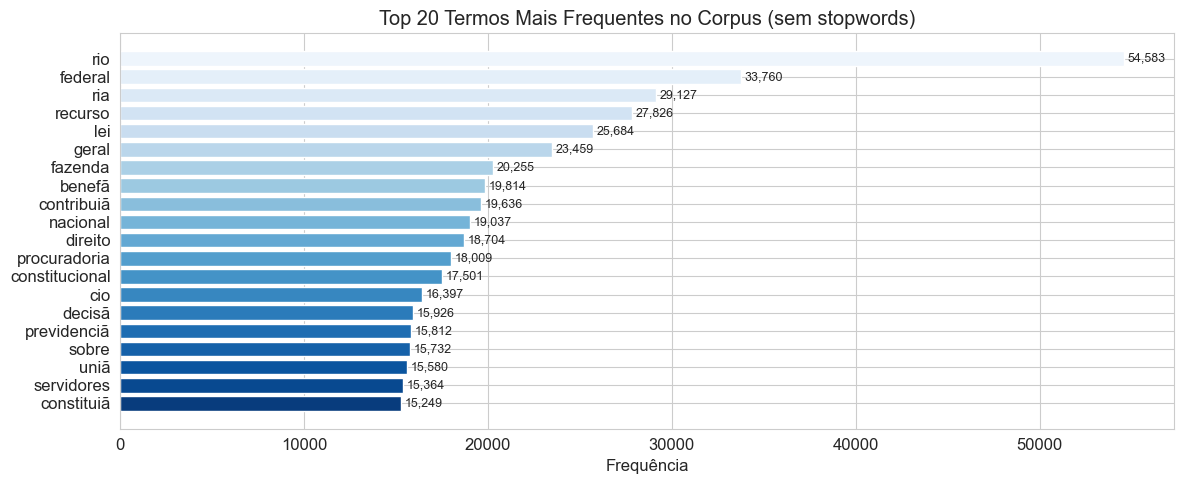

In [10]:
freq_global = ae.calcular_frequencia_global(train_valid)
ae.plotar_top_termos_global(freq_global)

* Análise: O que se torna visível é a confirmação da presença de erros nas palavras decorrentes da falta de tratamento e pré-processamento, algo que já foi levantado anteriormente.

### 8. Frequência de termos (por categoria)

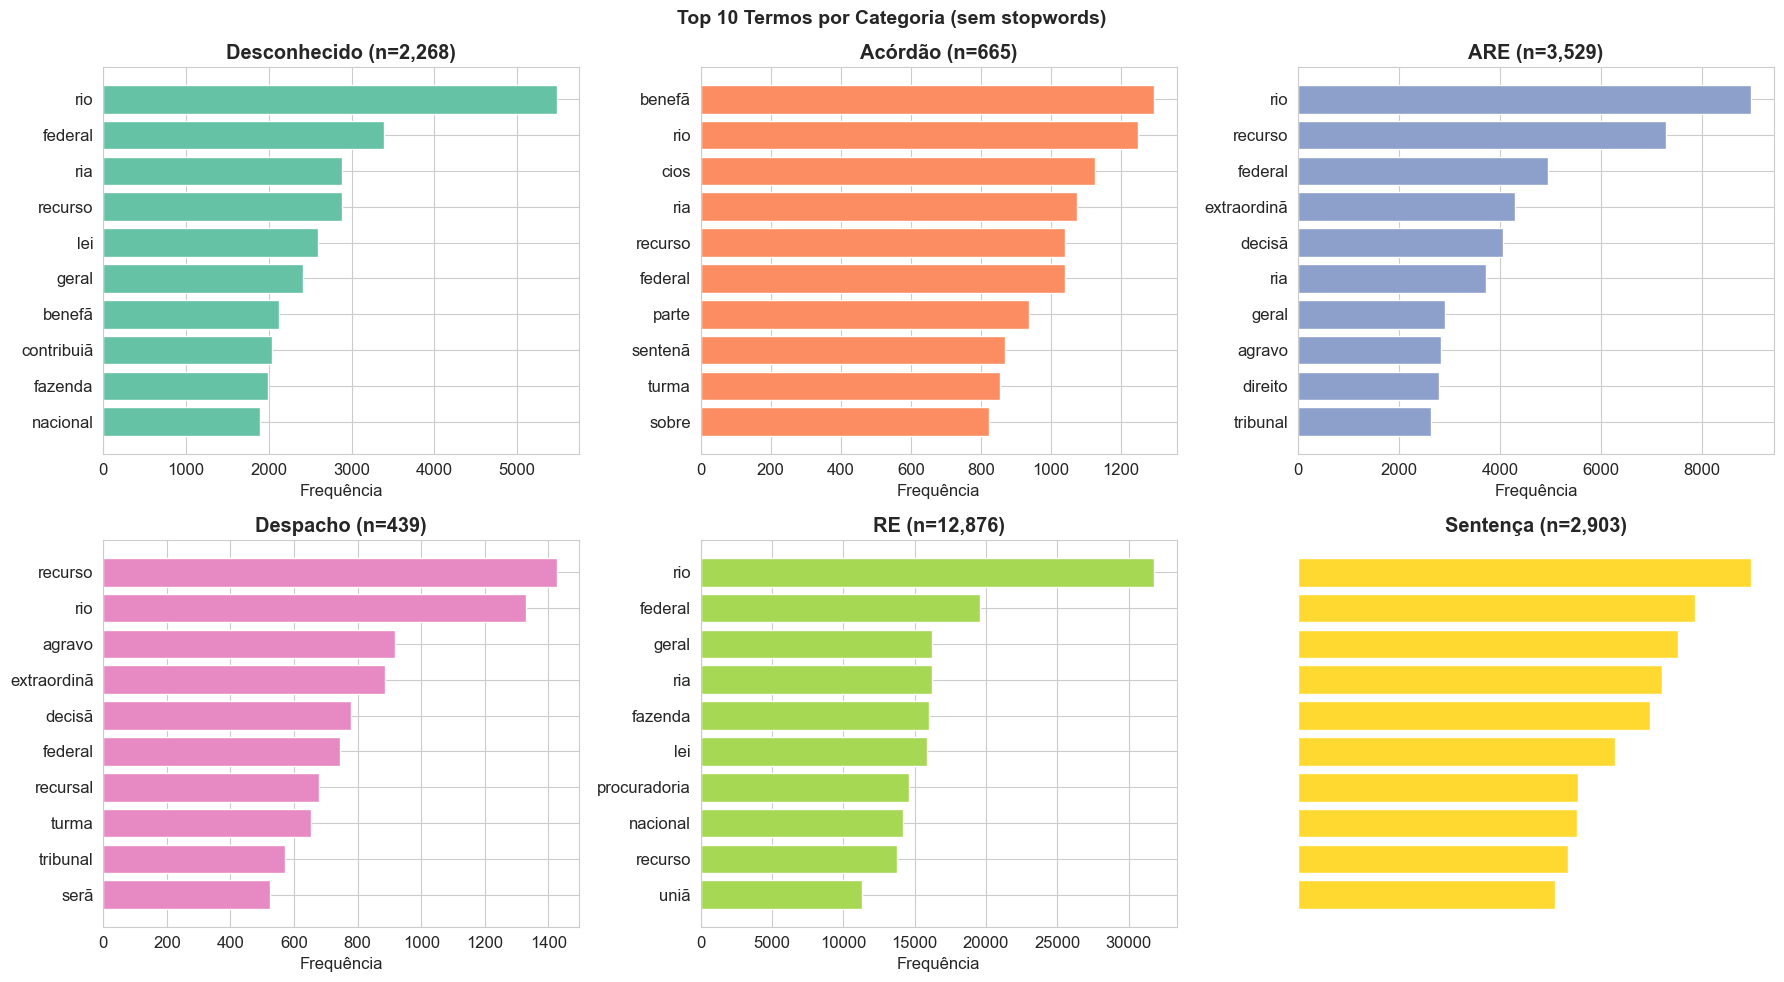

In [11]:
ae.plotar_top_termos_por_categoria(train_valid)

* Ainda se mostra evidente a presença de palavras errôneas com os erros de extração (sem correção).
Após a correção na etapa de Pré-processamento esses dados serão novamente mostrados para que seja confirmado a correção e o tratamento dos dados presentes.


1. Conexão Geral
* Existem palavras que aparecem no topo de quase todas as categorias, o que indica a natureza comum do dataset

* "rio": É o termo mais frequente em RE, ARE e Sentença, e o segundo em Acórdão e Despacho. Isso correlaciona fortemente todos os documentos a uma jurisdição específica (provavelmente Rio de Janeiro) ou a tribunais regionais.

* "federal": Presente em todos os gráficos. Reforça que a base de dados trata de matérias de competência da Justiça Federal ou instâncias superiores da União.

* "recurso": Onipresente, mas com peso maior em Despacho e ARE, onde a gestão do fluxo processual é o objetivo principal do documento.

2. Correlação por Cluster de Documentos
- Cluster de Admissibilidade e Rito (ARE, RE e Despacho)
- Estes documentos apresentam uma alta correlação terminológica voltada para o "caminho" do processo:

* Termos Chave: extraordinã (extraordinário), agravo, decisã (decisão).

* Análise: O ARE (Agravo em Recurso Extraordinário) e o Despacho compartilham quase os mesmos termos (agravo, extraordinário, decisão). Isso ocorre porque o Despacho, neste contexto, costuma ser o ato que decide sobre a subida ou não desses recursos.

* O "RE" (Recurso Extraordinário) se diferencia por trazer termos como fazenda, procuradoria e uniã, indicando que, no volume total, a maioria dos recursos extraordinários envolve entes públicos (União/Fazenda Nacional).

- Cluster de Decisão e Mérito (Sentença e Acórdão)
- Aqui a correlação muda do "procedimento" para o "direito discutido":

* Termos Chave: benefã (benefício), contribuí (contribuinte), lei, previdenciã (previdenciária).

* Análise: Existe uma correlação temática forte entre Sentença e Acórdão em torno de direitos sociais e tributários. O termo "benefã" (benefício) lidera os Acórdãos e está no topo das Sentenças, sugerindo que o grosso das decisões finais versa sobre benefícios (provavelmente previdenciários, dado o termo previdenciã na Sentença).

* Diferença: A Sentença foca mais no indivíduo/detalhe (contribuinte, servidores), enquanto o Acórdão mantém termos de colegiado (turma, cios - provavelmente de 'vencidos' ou 'unânimes').

3. Matriz de Especialidade
- RE (n=12.876): Correlaciona-se com a Administração Pública (fazenda, união, nacional).

- Sentença (n=2.903): Correlaciona-se com o Direito Previdenciário/Tributário (lei, contribuição, servidores).

- ARE e Despacho: Correlacionam-se com a Dinâmica de Instâncias Superiores (agravo, extraordinário).

- Conclusão da Análise
* A correlação sugere que o conjunto de dados é majoritariamente composto por contencioso de massa contra a União ou Autarquias Federais, concentrado no Rio de Janeiro. Enquanto os documentos de "meio" (ARE e Despacho) são puramente procedimentais, os documentos de "ponta" (Sentença e Acórdão) revelam que o tema central da disputa é o pagamento de benefícios e tributos.

### 9. Exemplos de texto por categoria

In [12]:
ae.exibir_exemplos_por_categoria(train_valid)

=== Exemplos de textos por categoria ===

--- Desconhecido (Categoria -1) ---
{"ARTIGO_16 serÃ¡ concedida nos termos regulamento indenizaÃ§Ã£o cr quatro mil duzentos cruzeiros por dia aos servidores que afastarem seu local trabalho sem direito percepÃ§Ã£o diÃ¡ria para execuÃ§Ã£o trabalhos campo tais como de campanhas combate controle endÃªmias marcaÃ§Ã£o inspeÃ§Ã£o manutenÃ§Ã£o marcos decisÃ³rios topografia pesquisa saneamento bÃ¡sico inspeÃ§Ã£o fiscalizaÃ§Ã£o fronteiras in
...

--- Acórdão (Categoria 0) ---
{"vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andrÃ© carvalho mendonÃ§a juiz federal relator"}
...

--- ARE (Categoria 1) ---
{"seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedimento possa ser considerado longo prazo razÃ£o disso passÃ­vel gerar acesso 

##### 1. Acórdão (Categoria 0)
Foco: Decisão Colegiada.

Análise: O texto é uma ementa ou dispositivo final. Utiliza fórmulas padrão de julgamento em grupo, como "unanimidade" e "negar provimento". É o documento que encerra uma fase processual em tribunais (neste caso, uma Turma Recursal em Pernambuco).

##### 2. ARE - Agravo em Recurso Extraordinário (Categoria 1)
Foco: Impugnação de bloqueio de recurso.

Análise: O texto ataca o "desacerto" de uma decisão anterior que impediu a subida de um Recurso Extraordinário. O conteúdo é focado em Assistência Social (Art. 203 da Constituição), discutindo critérios de deficiência e amparo assistencial (LOAS).

##### 3. Despacho (Categoria 2)
Foco: Admissibilidade e movimentação.

Análise: Funciona como um "filtro". O magistrado analisa se o recurso interposto (no caso, pela empresa GVT) atende aos requisitos do Art. 102 da Constituição. É um texto formal e administrativo que prepara o processo para o próximo passo.

##### 4. RE - Recurso Extraordinário (Categoria 3)
Foco: Argumentação da Parte (Petição).

Análise: Diferente dos anteriores, este fragmento tem um tom de súplica e convencimento ("espera e confia", "violação flagrante"). É a peça onde o advogado pede a reforma ou anulação de uma decisão, geralmente citando o Rio de Janeiro como sede.

##### 5. Sentença (Categoria 4)
Foco: Fundamentação de Mérito e Lei.

Análise: Este trecho é denso em doutrina e legislação. Discute prazos de decadência e a aplicação da Lei 9.784 em benefícios previdenciários. Enquanto o RE argumenta e o Despacho encaminha, a Sentença analisa o direito aplicado ao caso concreto.

### 10. Ruído textual (artefatos de OCR)

=== Métricas de ruído textual por categoria ===


,prop_especiais,prop_digitos,prop_maiusculas
Category_name,,,
Desconhecido,0.0293,0.0061,0.0466
Acórdão,0.0298,0.0064,0.0457
ARE,0.0273,0.0049,0.0409
Despacho,0.0287,0.0062,0.0439
RE,0.0292,0.0061,0.0476
Sentença,0.0313,0.0076,0.0527


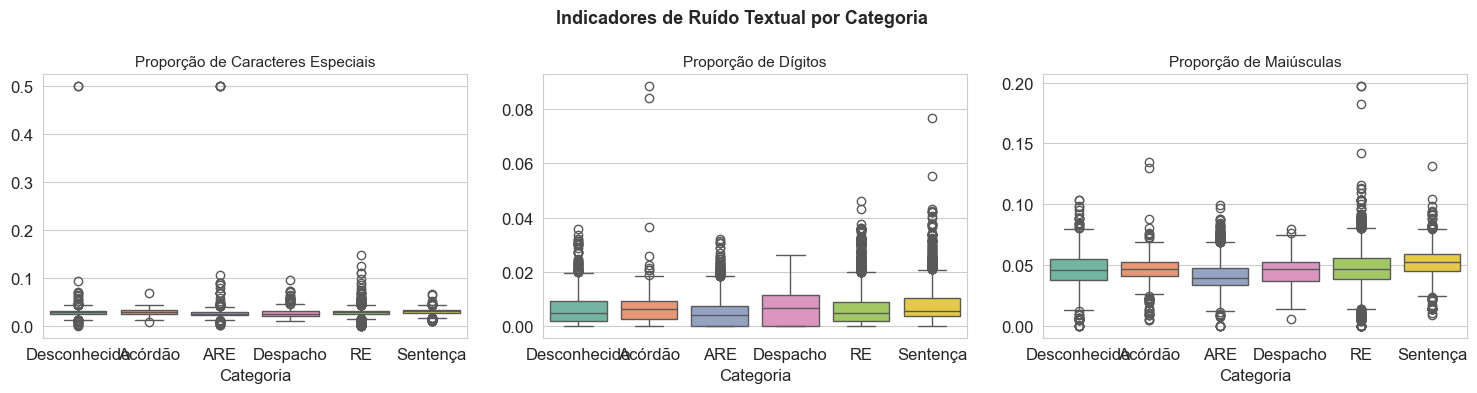

In [13]:
train_valid = ae.adicionar_metricas_ruido(train_valid)
ae.plotar_ruido_textual(train_valid)

1- Sentença é o "mais sujo": Lidera em caracteres especiais, números e letras maiúsculas por ser o documento de mérito mais detalhado.

2- ARE é o "mais limpo": Menor incidência de ruído, indicando um texto mais objetivo e menos técnico.

3- Anomalias (Outliers): Existem casos isolados no ARE com excesso de caracteres especiais (provável erro de OCR/conversão) e no Acórdão com muitos dígitos (prováveis tabelas de cálculos).

**Conclusão**: Para modelos de IA, as Sentenças exigem muito mais pré-processamento (limpeza) do que os AREs.

### 11. Resumo

In [14]:
ae.exibir_resumo(train_valid, test_df, freq_global, class_counts, class_pct)

         RESUMO DA ANÁLISE EXPLORATÓRIA
Amostras de treinamento (válidas) : 22,680
Amostras de teste                 : 2,521
Número de classes                 : 6
Tamanho do vocabulário            : 34,854 termos únicos
Média de palavras por documento   : 216
Mediana de palavras por documento : 209

Classes mais e menos representadas:
  Maior : RE (12,876 amostras, 56.8%)
  Menor : Despacho (439 amostras, 1.9%)

Observações para o pré-processamento:
  - Dataset desbalanceado: RE domina com ~56% dos dados.
  - Textos via OCR apresentam ruído (caracteres especiais).
  - Carimbos e assinaturas adicionam tokens irrelevantes.
  - Alto percentual de maiúsculas em cabeçalhos.
  - Limpeza e normalização são etapas críticas.


---
## Pré-processamento


In [ ]:
import nltk
nltk.download('stopwords', quiet=True)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


True

### 1. Importação do módulo de pré-processamento

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import analise_exploratoria as ae
from scripts import preprocessamento as pp

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

train_df, test_df, sample_submission = ae.carregar_dados(
    '../dados/train.csv', '../dados/test.csv', '../dados/sample_submission.csv'
)
train_valid = ae.filtrar_categorias_validas(train_df)

print(f'Treino (válido) : {len(train_valid):,} amostras')
print(f'Teste           : {len(test_df):,} amostras')

Treinamento : (22680, 3)
Teste       : (2521, 2)
Submissão   : (15, 2)
Treino (válido) : 22,680 amostras
Teste           : 2,521 amostras


### 2. Estratégia de limpeza

São adotados dois níveis de limpeza, com base em Martins (2024) e Araujo et al. (2020):

| Nível | O que faz | Usado em |
|-------|-----------|----------|
| **Limpeza básica** | Extração do wrapper JSON · Correção de encoding (mojibake) · Unicode NFC · Minúsculas · Remove URLs, e-mails e referências de folhas (`fl.`, `fls.`, `pg.`) | Word2Vec · FastText · BERT · BiLSTM · todos os modelos neurais |
| **Limpeza completa** | Básica + Remove ruído OCR + Remove números isolados + Remove stopwords (NLTK pt) | TF-IDF + SVM · TF-IDF + Regressão Logística |

> **Justificativa:** Modelos neurais aprendem contexto sequencial — remover stopwords eliminaria relações importantes (ex.: 'não provimento'). Já o TF-IDF representa o texto como uma sacola de palavras, onde stopwords apenas geram ruído sem agregar valor discriminativo.

### 3. Demonstração em um documento

Antes de processar o corpus inteiro, visualizamos o efeito de cada nível em um único exemplo.

In [ ]:
exemplo = train_valid[train_valid['Category'] == 0]['Body'].iloc[0]

pp.mostrar_exemplo(exemplo, n_chars=300)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


──────────────────────────────────────────────────────────────
EFEITO DO PRE-PROCESSAMENTO (exemplo)
──────────────────────────────────────────────────────────────

ORIGINAL  (29 tokens):
  {"vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andrÃ© carvalho mendonÃ§a juiz federal relator"}...

LIMPEZA BASICA  (29 tokens):
  vistos etc decide segunda turma recursal dos juizados especiais federais pernambuco unanimidade negar provimento recurso nos termos voto acima recife data julgamento jorge andré carvalho mendonça juiz federal relator...

LIMPEZA COMPLETA  (27 tokens):
  vistos etc decide segunda turma recursal juizados especiais federais pernambuco unanimidade negar provimento recurso termos voto acima recife data julgamento jorge andré carvalho mendonça juiz federal relator...

LIMPEZA LEMATIZADA  (27 tokens):
  visto etc decidir segundo turma recursal juizado e

### 4. Aplicação da limpeza básica

Aplicada ao conjunto de treino e de teste.

In [ ]:
train_basico = pp.preprocessar(train_valid, nivel='basica')
test_basico  = pp.preprocessar(test_df,     nivel='basica')

print('Exemplo (treino):')
print(' ', train_basico['Body_basica'].iloc[0][:300])

──────────────────────────────────────────────────
 Limpeza basica — 22,680 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_basica
  Tokens (media) : 216 -> 216  (reducao de 0.1%)

──────────────────────────────────────────────────
 Limpeza basica — 2,521 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_basica
  Tokens (media) : 218 -> 218  (reducao de 0.0%)

Exemplo (treino):
  conclusão diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_102 iii constituição federal será admitido conhecido provido fim que seja anulado v acórdão impugnado assim não entender que seja inteiramente reformado por violação flagrante aos dispositivos co


### 5. Aplicação da limpeza completa

Aplicada ao conjunto de treino e de teste.

In [ ]:
train_completo = pp.preprocessar(train_valid, nivel='completa')
test_completo  = pp.preprocessar(test_df,     nivel='completa')

print('Exemplo (treino):')
print(' ', train_completo['Body_completa'].iloc[0][:300])

──────────────────────────────────────────────────
 Limpeza completa — 22,680 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_completa
  Tokens (media) : 216 -> 175  (reducao de 19.0%)

──────────────────────────────────────────────────
 Limpeza completa — 2,521 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_completa
  Tokens (media) : 218 -> 177  (reducao de 18.9%)

Exemplo (treino):
  conclusão diante exposto recorrente espera confia recurso ora arrazoado interposto fulcro artigo_102 iii constituição federal admitido conhecido provido fim anulado acórdão impugnado assim entender inteiramente reformado violação flagrante dispositivos constitucionais suscitados razões recursais esp


### 6. Consolidação dos resultados

Montamos um DataFrame único com os três estágios (original, básico e completo) para facilitar as comparações a seguir.

In [20]:
import pandas as pd

df_comp = train_valid[['Id', 'Category', 'Body']].copy()
df_comp['Body_basica']    = train_basico['Body_basica']
df_comp['Body_completa']  = train_completo['Body_completa']

print('Colunas disponíveis:', df_comp.columns.tolist())
df_comp.head(2)

Colunas disponíveis: ['Id', 'Category', 'Body', 'Body_basica', 'Body_completa']


,Id,Category,Body,Body_basica,Body_completa
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera ...",conclusão diante exposto recorrente espera con...,conclusão diante exposto recorrente espera con...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",artigo_55 gecen a gacen serão devidas aos titu...,artigo_55 gecen gacen devidas titulares empreg...


### 7. Comparação: distribuição de tokens por nível

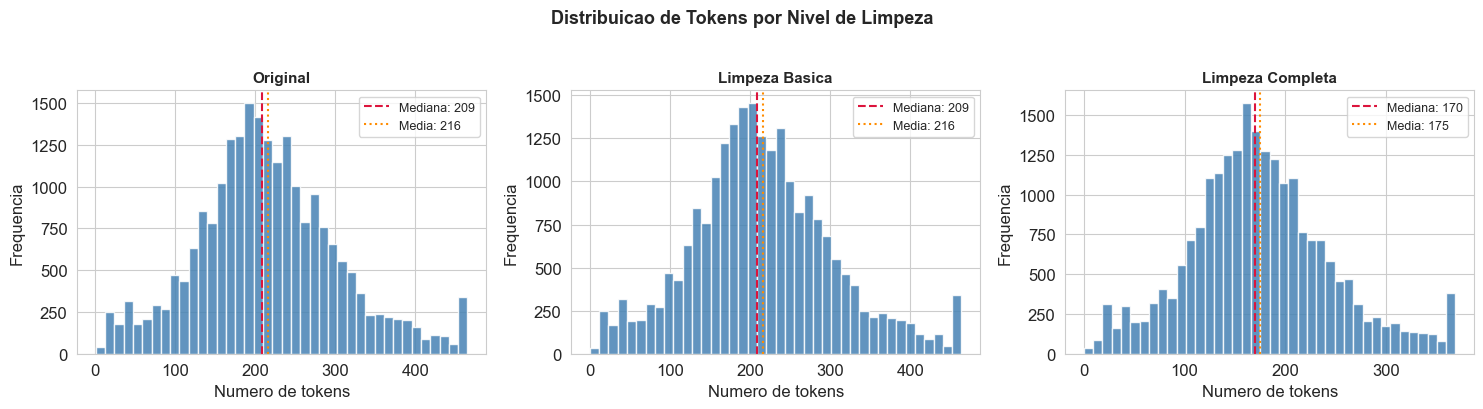

In [21]:
pp.plotar_tokens(df_comp)

### 8. Tabela comparativa

In [22]:
tabela = pp.tabela_comparativa(df_comp)
display(tabela)

,Media tokens,Mediana tokens,Vocabulario,Red. tokens (%),Red. vocab. (%)
Nivel,,,,,
Original,216.4,209.0,45486,0.0,0.0
Limpeza Basica,216.3,209.0,41208,0.1,9.4
Limpeza Completa,175.3,170.0,40571,19.0,10.8


### 9. Redução do vocabulário

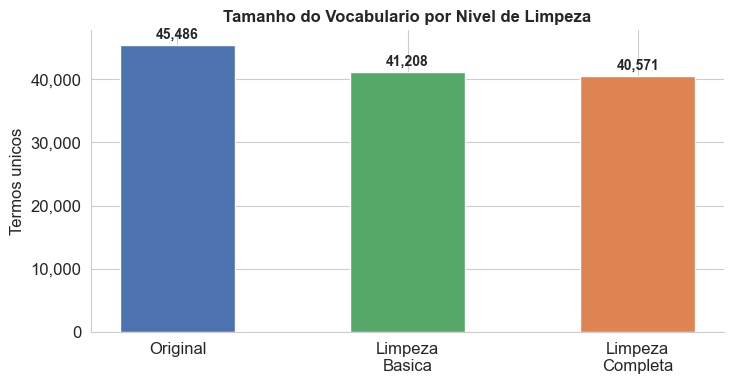

In [23]:
pp.plotar_vocabulario(df_comp)

### 10. Palavras mais frequentes — limpeza completa

Após remover stopwords, os termos restantes devem ser mais informativos e discriminativos entre as classes.

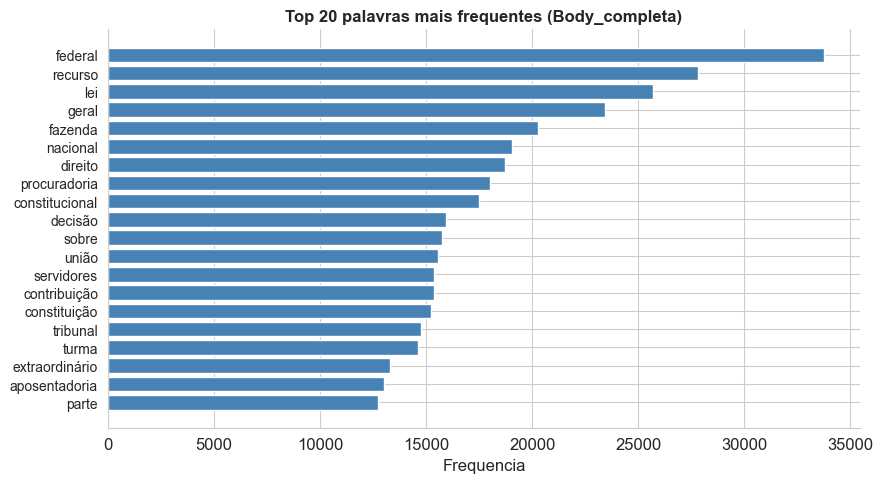

In [24]:
pp.plotar_top_palavras(df_comp, coluna='Body_completa', top_n=20)

### 11. Palavras mais frequentes por classe

Esta análise revela os termos mais característicos de cada tipo de documento, fornecendo intuição sobre quais features serão úteis para os classificadores.

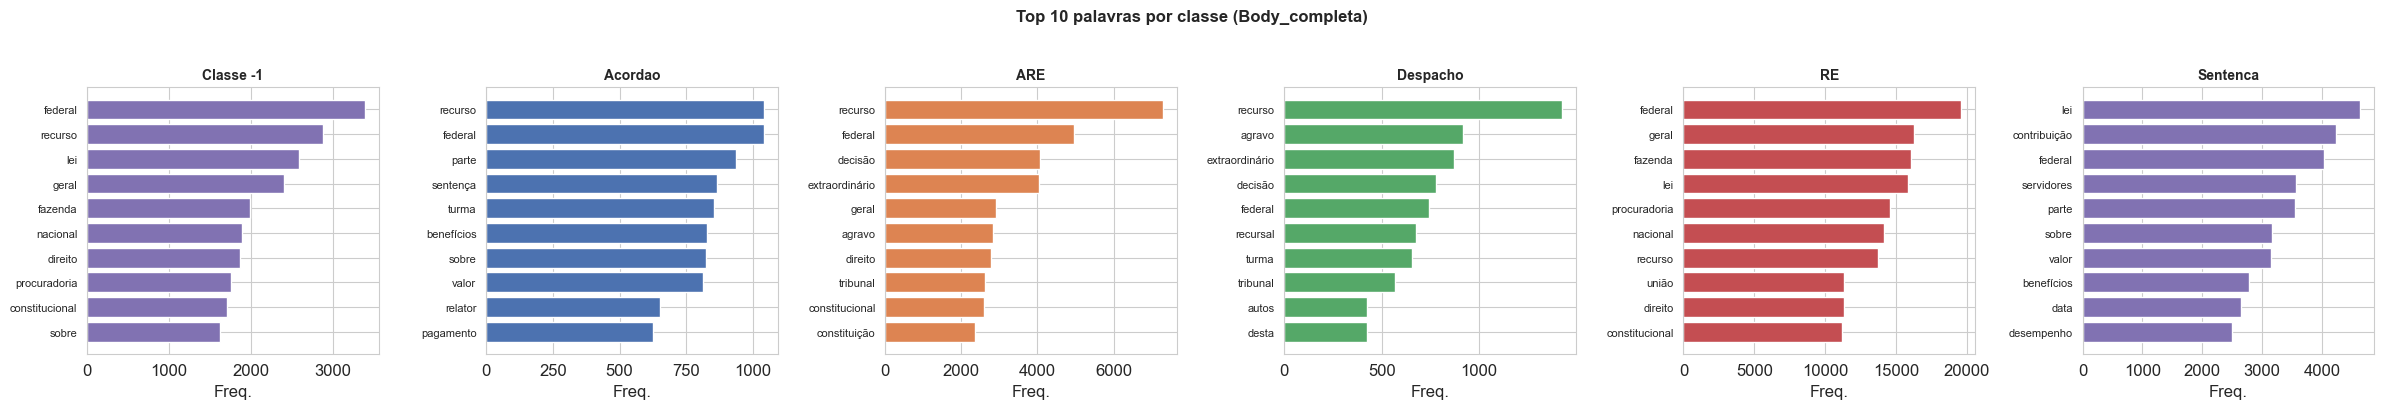

In [25]:
pp.plotar_top_palavras_por_classe(df_comp,
                                  coluna='Body_completa',
                                  top_n=10)

In [ ]:
train_lema = pp.preprocessar(train_valid, nivel='lematizada')
test_lema  = pp.preprocessar(test_df,     nivel='lematizada')
 
df_comp['Body_lematizada'] = train_lema['Body_lematizada']
print('Exemplo lematizado:', train_lema['Body_lematizada'].iloc[0][:200])

──────────────────────────────────────────────────
 Limpeza lematizada — 22,680 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_lematizada
  Tokens (media) : 216 -> 173  (reducao de 19.9%)

──────────────────────────────────────────────────
 Limpeza lematizada — 2,521 documentos
──────────────────────────────────────────────────
  Coluna criada  : Body_lematizada
  Tokens (media) : 218 -> 175  (reducao de 19.8%)

Exemplo lematizado: conclusão diante expor recorrente esperar confio recurso ora arrazoar interposto fulcro artigo_102 iii constituição federal admitir conhecer provir fim anular acórdão impugnar assim entender inteirame


In [ ]:
try:
    import cudf
    from cuml.feature_extraction.text import TfidfVectorizer
    
    print("🚀 Ambiente GPU detectado! Usando cuDF e cuML...")
    textos_treino = cudf.Series(train_lema['Body_lematizada'])
    textos_teste = cudf.Series(test_lema['Body_lematizada'])

except ImportError:
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    print(" Ambiente CPU detectado! Usando Pandas e Scikit-Learn...")
    textos_treino = train_lema['Body_lematizada']
    textos_teste = test_lema['Body_lematizada']


print("Iniciando a vetorização...")
vec_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_tfidf = vec_tfidf.fit_transform(textos_treino)
X_test_tfidf = vec_tfidf.transform(textos_teste)

print("Vetorização concluída!")

💻 Ambiente CPU detectado! Usando Pandas e Scikit-Learn...
Iniciando a vetorização...
Vetorização concluída!


In [28]:
D_densa_treino, D_densa_teste, modelo_w2v = pp.vetorizar_densa(
    train_basico['Body_basica'],
    test_basico['Body_basica'],
    vector_size=100,
    sg=1,
)
print('Vizinhos de "recurso":',
      [w for w, _ in modelo_w2v.wv.most_similar('recurso', topn=5)])

  Word2Vec (densa)
    Vocabulario : 27,589 termos
    Dimensao    : 100

Vizinhos de "recurso": ['extraordinário', 'interposto', 'destrancamento', 'intempestivo', 'retenho']


In [ ]:
import os

if os.path.exists('/kaggle/working'):
    pasta_representacoes = '/kaggle/working/dados/representacoes'
else:
    pasta_representacoes = '../dados/representacoes'

os.makedirs(pasta_representacoes, exist_ok=True)

try:
    X_treino_cpu = X_train_tfidf.get()
    X_teste_cpu = X_test_tfidf.get()
    print("Matrizes transferidas da GPU para a CPU.")
except AttributeError:
    X_treino_cpu = X_train_tfidf
    X_teste_cpu = X_test_tfidf
    print("Matrizes já estavam na CPU.")

pp.salvar_representacoes(
    pasta_representacoes, 
    X_tfidf_treino=X_treino_cpu, 
    X_tfidf_teste=X_teste_cpu, 
    vetorizador_tfidf=vec_tfidf,
    D_densa_treino=D_densa_treino, 
    D_densa_teste=D_densa_teste,   
    modelo_w2v=modelo_w2v,         
    y_treino=train_valid['Category'].values,
    ids_teste=test_df['Id'].values,
)

print(f"Arquivos salvos com sucesso na pasta: {pasta_representacoes}")

Matrizes já estavam na CPU.
  8 artefato(s) salvo(s) em /kaggle/working/dados/representacoes:
    - tfidf_treino.npz
    - tfidf_teste.npz
    - tfidf_vectorizer.joblib
    - densa_treino.npy
    - densa_teste.npy
    - word2vec.model
    - y_treino.npy
    - ids_teste.npy
Arquivos salvos com sucesso na pasta: /kaggle/working/dados/representacoes


### 12. Resumo e conclusões do pré-processamento

In [30]:
pp.exibir_resumo(train_valid, df_comp)


  RESUMO DO PRE-PROCESSAMENTO
  Documentos processados : 22,680

  [Basica]
    Tokens medios  : 216 -> 216  (reducao de 0.1%)
    Vocabulario    : 41,208 termos unicos

  [Completa]
    Tokens medios  : 216 -> 175  (reducao de 19.0%)
    Vocabulario    : 40,571 termos unicos

  [Lematizada]
    Tokens medios  : 216 -> 173  (reducao de 19.9%)
    Vocabulario    : 33,594 termos unicos




### 13. Extração de Atributos de PLN (POS Tagging e NER)

Nesta etapa, estendemos o pré-processamento aplicando tarefas fundamentais de PLN por meio da biblioteca `spaCy` para capturar propriedades sintáticas e estruturais do "juridiquês". Os atributos gerados servem como engenharia de atributos (*feature engineering*) para os modelos classificadores clássicos:

* **Reconhecimento de Entidades Nomeadas (NER):** Mapeamento e contagem de entidades (como órgãos públicos, leis, pessoas) citadas ao longo da página.
* **Etiquetagem Morfológica (POS Tagging):** Mensuração da quantidade absoluta de substantivos e verbos, ajudando a traçar o perfil de densidade de termos de cada classe documental.

In [ ]:
print("Extraindo atributos sintáticos e estruturais via spaCy...")

train_basico['num_entidades'], train_basico['num_substantivos'], train_basico['num_verbos'] = zip(*train_basico['Body'].map(pp.extrair_atributos_pln))
test_basico['num_entidades'], test_basico['num_substantivos'], test_basico['num_verbos'] = zip(*test_basico['Body'].map(pp.extrair_atributos_pln))

print("Atributos sintáticos extraídos com sucesso!")
train_basico[['num_entidades', 'num_substantivos', 'num_verbos']].head()

Extraindo atributos sintáticos e estruturais via spaCy...
Atributos sintáticos extraídos com sucesso!


,num_entidades,num_substantivos,num_verbos
0,3,12,16
1,12,40,25
2,9,52,41
3,22,73,58
4,17,119,114


### 14. Representação Computacional Esparsa (TF-IDF)

Para tornar os textos compreensíveis aos algoritmos de aprendizado de máquina tradicionais, convertemos o corpus limpo em matrizes matemáticas utilizando a abordagem de frequência de termo–inverso da frequência nos documentos (TF-IDF):

* **Configuração do Vocabulário:** Definição do limite de *features* mais frequentes para otimização de memória.
* **Contexto de N-gramas:** Extração de unigramas e bigramas simultaneamente para capturar expressões compostas comuns no vocabulário técnico do STF.

In [ ]:
import pickle

print("Gerando matrizes esparsas de representação vetorial...")

X_train_tfidf, X_test_tfidf, tfidf_model = pp.gerar_representacao_tfidf(
    df_treino=train_completo, 
    df_teste=test_completo, 
    coluna='Body_completa', 
    max_features=10000
)

with open('../dados/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_model, f)

print(f"Matriz TF-IDF de Treino criada com dimensões: {X_train_tfidf.shape}")
print(f"Matriz TF-IDF de Teste criada com dimensões: {X_test_tfidf.shape}")

Gerando matrizes esparsas de representação vetorial...
Matriz TF-IDF de Treino criada com dimensões: (22680, 10000)
Matriz TF-IDF de Teste criada com dimensões: (2521, 10000)


### 15. Salvamento dos dados processados

In [33]:
train_basico[['Id','Category','Body_basica']].to_csv(
    '../dados/train_basico.csv', index=False
)
train_completo[['Id','Category','Body_completa']].to_csv(
    '../dados/train_completo.csv', index=False
)

test_basico[['Id','Body_basica']].to_csv(
    '../dados/test_basico.csv', index=False
)
test_completo[['Id','Body_completa']].to_csv(
    '../dados/test_completo.csv', index=False
)

print('Arquivos salvos com sucesso.')

Arquivos salvos com sucesso.


---
## Experimento

Nesta seção os modelos são treinados, ajustados e avaliados sobre os dados pré-processados.  
A seção está organizada em quatro subseções:

1. **Configuração e carregamento** – carrega as representações salvas e define utilitários de avaliação  
2. **Modelos Clássicos** – Naïve Bayes, Regressão Logística e SVM com TF-IDF  
3. **Modelos Profundos** *(seção reservada)*  
4. **Transformers / LMs** *(seção reservada)*

### 3.1 Configuração e carregamento

Carregamos as matrizes TF-IDF e o vetor de rótulos gerados na etapa de pré-processamento.  
Também definimos nomes de classes, semente aleatória e as funções utilitárias de avaliação que  
serão reutilizadas ao longo de todos os experimentos.

In [34]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import experimentos as exp

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Módulo experimentos importado com sucesso.')

Módulo experimentos importado com sucesso.


In [35]:
(
    X_train_tfidf, X_test_tfidf,
    y_train,
    tfidf_vectorizer,
    train_completo, test_completo,
) = exp.carregar_representacoes_tfidf()

X_train_tfidf : (20412, 10000)
X_test_tfidf  : (2521, 10000)
y_train       : (20412,)  | classes: [0 1 2 3 4]


### 3.2 Modelos Clássicos — TF-IDF + Naïve Bayes, Regressão Logística e SVM

Treinamos três classificadores clássicos sobre a representação TF-IDF com limpeza completa.  
Para cada modelo:

1. Avaliamos com validação cruzada estratificada (5-fold) usando **F1-macro** como métrica principal.  
2. Realizamos busca de hiperparâmetros com **GridSearchCV** (3-fold interno).  
3. Exibimos a matriz de confusão e o relatório de classificação.  
4. Geramos o CSV de submissão para o Kaggle.

> **Nota sobre `class_weight='balanced'`:** dado o desbalanceamento extremo (RE domina ~60 % das amostras),  
> os modelos lineares usam pesos inversamente proporcionais à frequência das classes.

#### 3.2.1 Naïve Bayes Multinomial (Complement NB)

O Complement NB modela a probabilidade de cada termo dado o **complemento** da classe,  
sendo mais robusto ao desbalanceamento que o Multinomial NB padrão (Rennie et al., 2003).  
Serve como *baseline* probabilístico eficiente.

**Hiperparâmetro:** `alpha` (suavização de Laplace).

In [36]:
gs_nb, resultado_nb, best_nb = exp.treinar_naive_bayes(X_train_tfidf, y_train)

NAÏVE BAYES — busca de hiperparâmetros (GridSearchCV)
  Melhor alpha  : 0.01
  F1-macro (CV) : 0.7377
  Complement NB (melhor alpha)            F1-macro=0.7388 (+/-0.0111)  acc=0.7834  tempo=0.6s


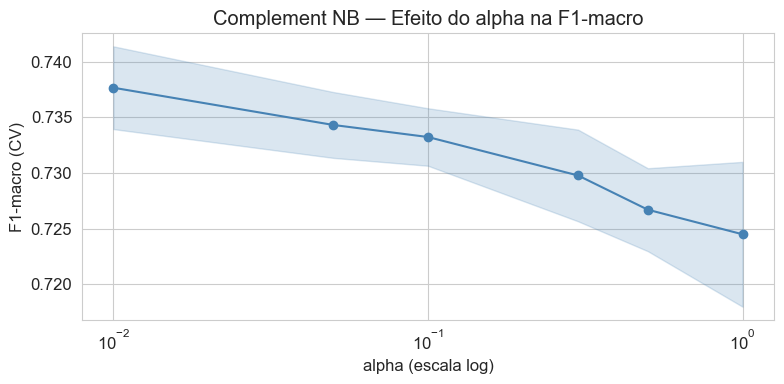

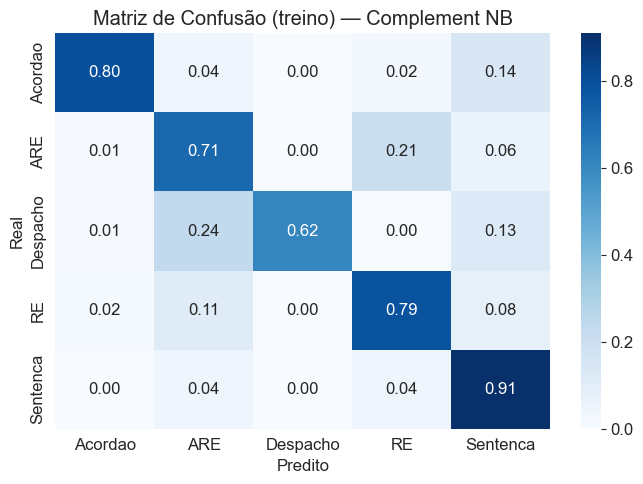

              precision    recall  f1-score   support

     Acordao       0.68      0.80      0.73       665
         ARE       0.60      0.71      0.65      3529
    Despacho       0.94      0.62      0.74       439
          RE       0.92      0.79      0.85     12876
    Sentenca       0.65      0.91      0.76      2903

    accuracy                           0.79     20412
   macro avg       0.76      0.77      0.75     20412
weighted avg       0.82      0.79      0.80     20412



In [37]:
exp.plotar_curva_alpha_nb(gs_nb)
exp.plotar_matriz_confusao(
    'Complement NB',
    exp._build_nb(gs_nb.best_params_),
    X_train_tfidf, y_train,
)

#### 3.2.2 Regressão Logística

Classificador linear com regularização L2 e `class_weight='balanced'`.  
Solver `saga` converge eficientemente em matrizes esparsas de alta dimensão.  
Os coeficientes aprendidos são interpretáveis: permitem identificar os termos  
mais discriminativos por classe.

**Hiperparâmetro:** `C` (inverso da regularização).

In [38]:
gs_lr, resultado_lr, best_lr = exp.treinar_regressao_logistica(X_train_tfidf, y_train)

REGRESSÃO LOGÍSTICA — busca de hiperparâmetros (GridSearchCV)
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Melhores params : {'C': 10.0, 'penalty': 'l2'}
  F1-macro (CV)   : 0.8899
  Regressão Logística (melhor C)          F1-macro=0.8986 (+/-0.0049)  acc=0.9124  tempo=12.8s


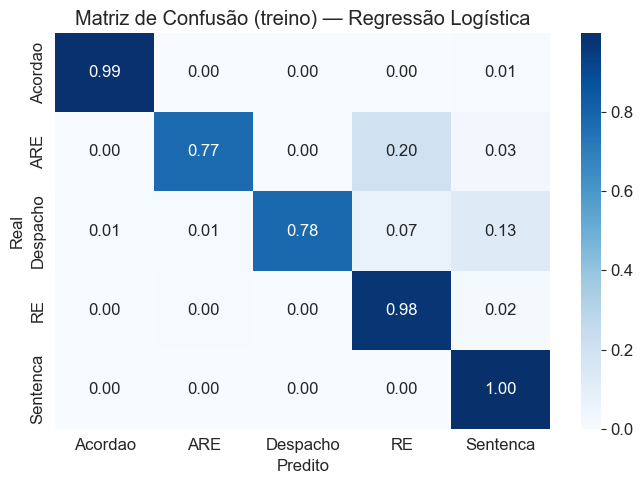

              precision    recall  f1-score   support

     Acordao       0.92      0.99      0.96       665
         ARE       0.98      0.77      0.86      3529
    Despacho       1.00      0.78      0.88       439
          RE       0.95      0.98      0.96     12876
    Sentenca       0.89      1.00      0.94      2903

    accuracy                           0.94     20412
   macro avg       0.95      0.90      0.92     20412
weighted avg       0.94      0.94      0.94     20412



In [39]:
exp.plotar_matriz_confusao(
    'Regressão Logística',
    exp._build_lr(gs_lr.best_params_),
    X_train_tfidf, y_train,
)

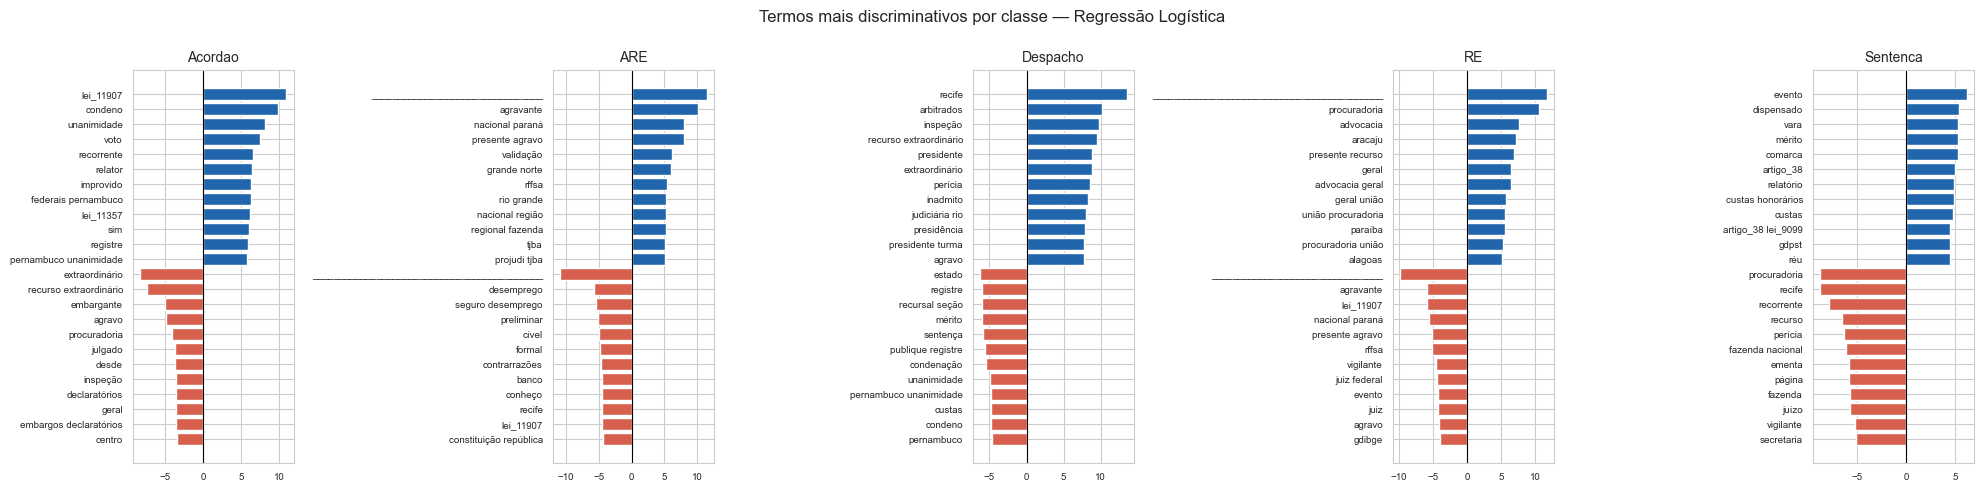

In [40]:
best_lr_coef = exp._build_lr(gs_lr.best_params_)
best_lr_coef.fit(X_train_tfidf, y_train)

exp.plotar_coeficientes_lr(best_lr_coef, tfidf_vectorizer)

#### 3.2.3 Máquina de Vetores de Suporte — SVM Linear

`SGDClassifier(loss='hinge')` implementa um SVM linear via gradiente estocástico,  
altamente eficiente em matrizes TF-IDF esparsas de alta dimensão.  
A estratégia de margem máxima tende a superar a RL em vocabulários muito grandes.

**Hiperparâmetros:** `alpha` (regularização L2) e `class_weight`.

In [41]:
gs_svm, resultado_svm, best_svm = exp.treinar_svm(X_train_tfidf, y_train)

SVM LINEAR (SGD) — busca de hiperparâmetros (GridSearchCV)
  Melhores params : {'alpha': 1e-05, 'class_weight': None}
  F1-macro (CV)   : 0.8929
  SVM Linear/SGD (melhores params)        F1-macro=0.8992 (+/-0.0100)  acc=0.9188  tempo=17.0s


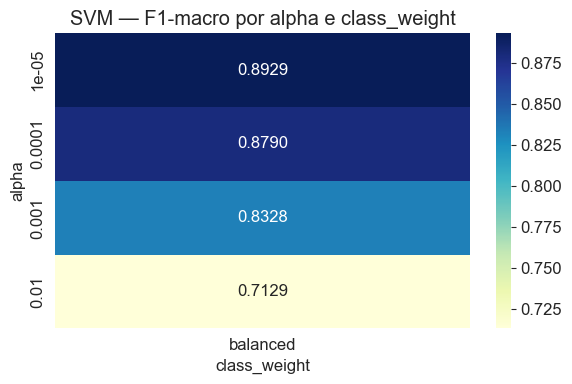

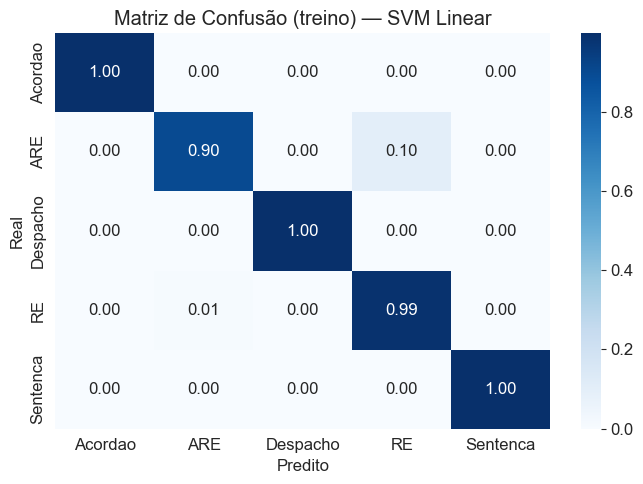

              precision    recall  f1-score   support

     Acordao       0.97      1.00      0.98       665
         ARE       0.96      0.90      0.93      3529
    Despacho       0.98      1.00      0.99       439
          RE       0.97      0.99      0.98     12876
    Sentenca       1.00      1.00      1.00      2903

    accuracy                           0.97     20412
   macro avg       0.98      0.98      0.98     20412
weighted avg       0.97      0.97      0.97     20412



In [42]:
exp.plotar_heatmap_svm(gs_svm)

exp.plotar_matriz_confusao(
    'SVM Linear',
    exp._build_svm(gs_svm.best_params_),
    X_train_tfidf, y_train,
)

#### 3.2.4 Comparação dos Modelos Clássicos e Geração de Submissões

Consolidamos os resultados dos três classificadores e geramos os CSVs de  
submissão para o Kaggle com o modelo treinado em todo o conjunto de treino.

In [43]:
resultados_classicos, display_classicos = exp.tabela_comparativa_classicos(
    [resultado_nb, resultado_lr, resultado_svm]
)
display(display_classicos)


COMPARATIVO — MODELOS CLÁSSICOS (TF-IDF + Limpeza Completa)


,F1-Macro (media),F1-Macro (std),F1-Weighted (media),Acuracia (media),Tempo CV (s)
Modelo,,,,,
Complement NB (melhor alpha),0.7388,0.0111,0.7895,0.7834,0.6s
Regressão Logística (melhor C),0.8986,0.0049,0.9140,0.9124,12.8s
SVM Linear/SGD (melhores params),0.8992,0.0100,0.9179,0.9188,17.0s


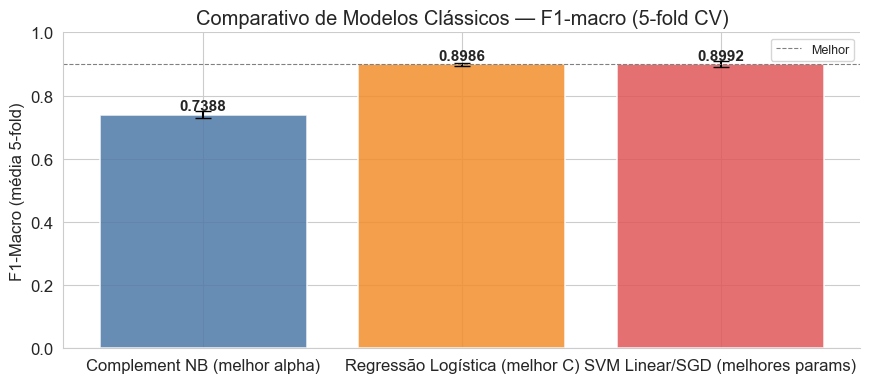

In [44]:
exp.plotar_comparativo_classicos(resultados_classicos)

In [45]:
ids_teste = test_completo['Id'].values

nb_sub  = exp.gerar_submissao_classico(
    'submission_nb.csv',  exp._build_nb(gs_nb.best_params_),
    X_train_tfidf, y_train, X_test_tfidf, ids_teste,
)
lr_sub  = exp.gerar_submissao_classico(
    'submission_lr.csv',  exp._build_lr(gs_lr.best_params_),
    X_train_tfidf, y_train, X_test_tfidf, ids_teste,
)
svm_sub = exp.gerar_submissao_classico(
    'submission_svm.csv', exp._build_svm(gs_svm.best_params_),
    X_train_tfidf, y_train, X_test_tfidf, ids_teste,
)

print('\n[NB]');  display(nb_sub.head(3))
print('\n[LR]');  display(lr_sub.head(3))
print('\n[SVM]'); display(svm_sub.head(3))

  Submissão salva em: ..\dados\submission_nb.csv  (2521 registros)
  Submissão salva em: ..\dados\submission_lr.csv  (2521 registros)
  Submissão salva em: ..\dados\submission_svm.csv  (2521 registros)

[NB]


,Id,Category
0,9213,0
1,17427,1
2,4753,3



[LR]


,Id,Category
0,9213,0
1,17427,3
2,4753,3



[SVM]


,Id,Category
0,9213,0
1,17427,1
2,4753,3


In [46]:
exp.treinar_e_salvar_classico(
    'complement_nb.pkl',      exp._build_nb(gs_nb.best_params_),
    X_train_tfidf, y_train,
)
exp.treinar_e_salvar_classico(
    'logistic_regression.pkl', exp._build_lr(gs_lr.best_params_),
    X_train_tfidf, y_train,
)
exp.treinar_e_salvar_classico(
    'svm_sgd.pkl',             exp._build_svm(gs_svm.best_params_),
    X_train_tfidf, y_train,
)

  Salvo: ..\dados\modelos_classicos\complement_nb.pkl
  Salvo: ..\dados\modelos_classicos\logistic_regression.pkl
  Salvo: ..\dados\modelos_classicos\svm_sgd.pkl


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",1e-05
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",200
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


#### 3.2.5 Análise qualitativa dos modelos clássicos

**Complement NB** serve como *baseline* probabilístico.  
Por modelar o complemento de cada classe, lida melhor com o desbalanceamento  
do que o Multinomial NB clássico.

**Regressão Logística** com `class_weight='balanced'` é tipicamente o classificador  
linear mais robusto para texto — equilibra precisão e recall nas classes minoritárias  
(Acórdão e Despacho). Seus coeficientes são interpretáveis: os termos com maior  
peso positivo são os mais discriminativos para cada classe.

**SVM Linear** explora ao máximo a esparsidade do TF-IDF via margem máxima.  
Tende a superar a RL em vocabulários de alta dimensionalidade.

**Classes críticas:** Acórdão (0) e Despacho (2) possuem poucas amostras relativas.  
A análise da matriz de confusão e do F1 por classe revela se os modelos conseguem  
classificá-las corretamente — essencial antes de avançar para modelos mais complexos.


### 3.3 Modelos Profundos — BiLSTM e CNN para Texto

Modelos neurais profundos capturam dependências sequenciais e padrões locais que os
modelos clássicos não conseguem representar.  
Utilizamos os embeddings Word2Vec (300d, skip-gram) gerados na etapa de pré-processamento
como camada de entrada pré-treinada, aproveitando o vocabulário do domínio jurídico.

Dois modelos são treinados e comparados:

| Modelo | Arquitetura | Intenção |
|--------|-------------|----------|
| **BiLSTM** | Embedding → BiLSTM → Dropout → Dense | Capturar contexto bidirecional |
| **CNN-Text** | Embedding → Conv1D (múltiplos filtros) → GlobalMaxPool → Dense | Capturar n-gramas locais |

> **Hardware:** o treinamento é feito em CPU/GPU transparentemente via TensorFlow/Keras.
> Para aceleração em Colab, ative o runtime GPU antes de executar esta seção.

In [47]:
tf = exp.configurar_tensorflow()

TensorFlow   : 2.21.0
GPUs visíveis: []
CPU threads  : 8


In [48]:
import pandas as pd

word2idx, VOCAB_SIZE = exp.construir_vocabulario(
    pd.read_csv(exp.DATA_DIR / 'train_basico.csv')
)

(
    X_seq_train, X_seq_test, y_nn,
    X_tr_nn, X_val_nn, y_tr_nn, y_val_nn,
) = exp.carregar_dados_neurais(word2idx)

Vocabulário  : 30,000 tokens
X_seq_train  : (20412, 300)
X_seq_test   : (2521, 300)
Hold-out     — treino: (17350, 300), val: (3062, 300)


In [49]:
embed_matrix, EMBED_DIM = exp.carregar_embedding_matrix(word2idx, VOCAB_SIZE)

Word2Vec carregado — dim=100, vocab=27,589
Cobertura da matriz de embedding: 91.4%  (27,411/30,000)


In [50]:
class_weights_nn = exp.calcular_pesos_classe(y_nn)

Pesos de classe: {'Acordao': 6.139, 'ARE': 1.157, 'Despacho': 9.299, 'RE': 0.317, 'Sentenca': 1.406}


#### 3.3.4 BiLSTM — Rede Recorrente Bidirecional

A BiLSTM processa cada sequência nos dois sentidos (esquerda→direita e direita→esquerda),
capturando dependências de longo alcance no texto jurídico.  
Usamos dois callbacks para regularização durante o treinamento:

- `EarlyStopping` — interrompe se a `val_loss` não melhora por 3 épocas;
- `ReduceLROnPlateau` — reduz a taxa de aprendizado ao plateaux de `val_loss`.

In [51]:
MAX_LEN = X_seq_train.shape[1]

bilstm_model = exp.construir_bilstm(
    VOCAB_SIZE, EMBED_DIM, embed_matrix, MAX_LEN
)
bilstm_model.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_w2v (Embedding)       │ (None, 300, 100)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 300, 256)       │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,416,005 (13.03 MB)

 Trainable params: 416,005 (1.59 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [52]:
hist_bilstm, _ = exp.treinar_modelo_nn(
    bilstm_model,
    X_tr_nn, y_tr_nn,
    X_val_nn, y_val_nn,
    class_weights_nn,
)

Epoch 1/20
68/68 - 366s - 5s/step - accuracy: 0.5951 - loss: 1.1327 - val_accuracy: 0.6924 - val_loss: 0.9039 - learning_rate: 0.0010
Epoch 2/20
68/68 - 392s - 6s/step - accuracy: 0.6551 - loss: 0.8367 - val_accuracy: 0.6525 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 3/20
68/68 - 384s - 6s/step - accuracy: 0.6638 - loss: 0.7463 - val_accuracy: 0.7322 - val_loss: 0.7088 - learning_rate: 0.0010
Epoch 4/20
68/68 - 335s - 5s/step - accuracy: 0.6705 - loss: 0.7087 - val_accuracy: 0.7155 - val_loss: 0.6741 - learning_rate: 0.0010
Epoch 5/20
68/68 - 369s - 5s/step - accuracy: 0.6930 - loss: 0.6654 - val_accuracy: 0.7159 - val_loss: 0.7060 - learning_rate: 0.0010
Epoch 6/20
68/68 - 298s - 4s/step - accuracy: 0.6813 - loss: 0.6567 - val_accuracy: 0.7433 - val_loss: 0.6230 - learning_rate: 0.0010
Epoch 7/20
68/68 - 414s - 6s/step - accuracy: 0.7014 - loss: 0.6043 - val_accuracy: 0.7502 - val_loss: 0.6042 - learning_rate: 0.0010
Epoch 8/20
68/68 - 492s - 7s/step - accuracy: 0.7133 - loss: 0

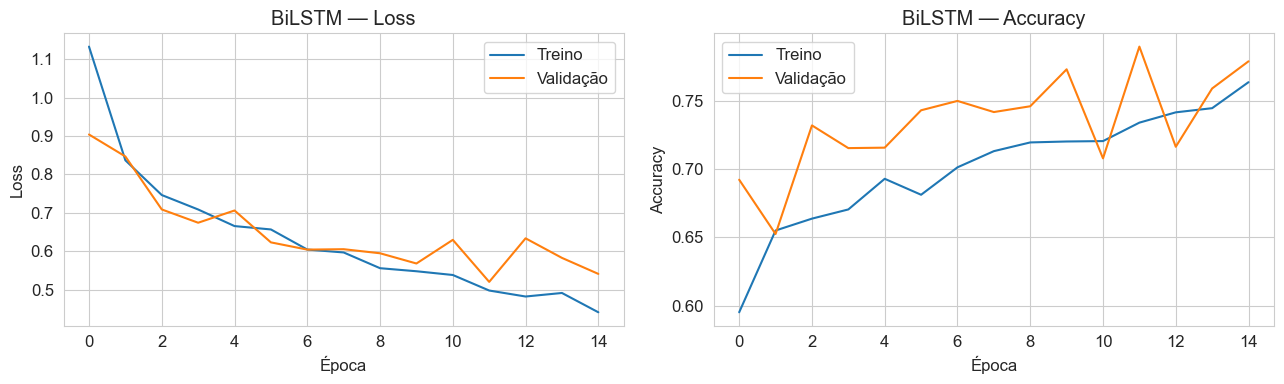

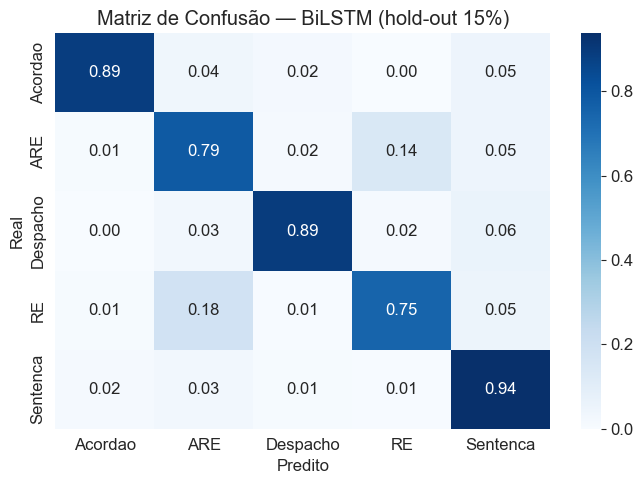

  BiLSTM (W2V embeddings)              F1-macro=0.7791  F1-weighted=0.7989  acc=0.7900

Relatório de classificação — BiLSTM (W2V embeddings) (hold-out):
              precision    recall  f1-score   support

     Acordao       0.75      0.89      0.81       100
         ARE       0.53      0.79      0.63       529
    Despacho       0.69      0.89      0.78        66
          RE       0.95      0.75      0.84      1932
    Sentenca       0.75      0.94      0.83       435

    accuracy                           0.79      3062
   macro avg       0.73      0.85      0.78      3062
weighted avg       0.84      0.79      0.80      3062



In [53]:
exp.plotar_historico(hist_bilstm, 'BiLSTM')
exp.plotar_matriz_confusao_nn('BiLSTM', bilstm_model, X_val_nn, y_val_nn, cmap='Blues')
resultado_bilstm = exp.avaliar_modelo_nn('BiLSTM (W2V embeddings)', bilstm_model, X_val_nn, y_val_nn)

#### 3.3.5 CNN para Texto — Redes Convolucionais 1D

A abordagem de TextCNN (Kim, 2014) aplica filtros convolucionais de múltiplos tamanhos
(uni, bi e trigramas) em paralelo sobre os embeddings, capturando padrões locais do
vocabulário jurídico sem custo computacional de RNNs.

Cada bloco `Conv1D → GlobalMaxPool1D` extrai a feature mais relevante de cada filtro
para toda a sequência, independentemente da sua posição.

In [54]:
cnn_model = exp.construir_textcnn(
    VOCAB_SIZE, EMBED_DIM, embed_matrix, MAX_LEN
)
cnn_model.summary()

Model: "TextCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_w2v       │ (None, 300, 100)  │  3,000,000 │ input_seq[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 300, 100)  │          0 │ embedding_w2v[0]… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2gram (Conv1D) │ (None, 300, 128)  │     25,728 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 300, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 300, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 300, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2gram          │ (None, 128)       │          0 │ conv_2gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3gram          │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4gram          │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5gram          │ (None, 128)       │          0 │ conv_5gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pools        │ (None, 512)       │          0 │ pool_2gram[0][0], │
│ (Concatenate)       │                   │            │ pool_3gram[0][0], │
│                     │                   │            │ pool_4gram[0][0], │
│                     │                   │            │ pool_5gram[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ concat_pools[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,327,813 (12.69 MB)

 Trainable params: 327,813 (1.25 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [55]:
hist_cnn, _ = exp.treinar_modelo_nn(
    cnn_model,
    X_tr_nn, y_tr_nn,
    X_val_nn, y_val_nn,
    class_weights_nn,
    patience_stop=4,
)

Epoch 1/20
68/68 - 31s - 462ms/step - accuracy: 0.3288 - loss: 1.4824 - val_accuracy: 0.7093 - val_loss: 0.9110 - learning_rate: 0.0010
Epoch 2/20
68/68 - 27s - 398ms/step - accuracy: 0.6250 - loss: 0.8234 - val_accuracy: 0.7342 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 3/20
68/68 - 41s - 602ms/step - accuracy: 0.6911 - loss: 0.6065 - val_accuracy: 0.7694 - val_loss: 0.5498 - learning_rate: 0.0010
Epoch 4/20
68/68 - 27s - 398ms/step - accuracy: 0.7237 - loss: 0.5086 - val_accuracy: 0.8201 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 5/20
68/68 - 28s - 406ms/step - accuracy: 0.7366 - loss: 0.4372 - val_accuracy: 0.8328 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 6/20
68/68 - 27s - 402ms/step - accuracy: 0.7656 - loss: 0.3796 - val_accuracy: 0.7609 - val_loss: 0.4722 - learning_rate: 0.0010
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
68/68 - 27s - 393ms/step - accuracy: 0.7756 - loss: 0.3327 - val_accuracy: 0.7946 - val_loss: 0.

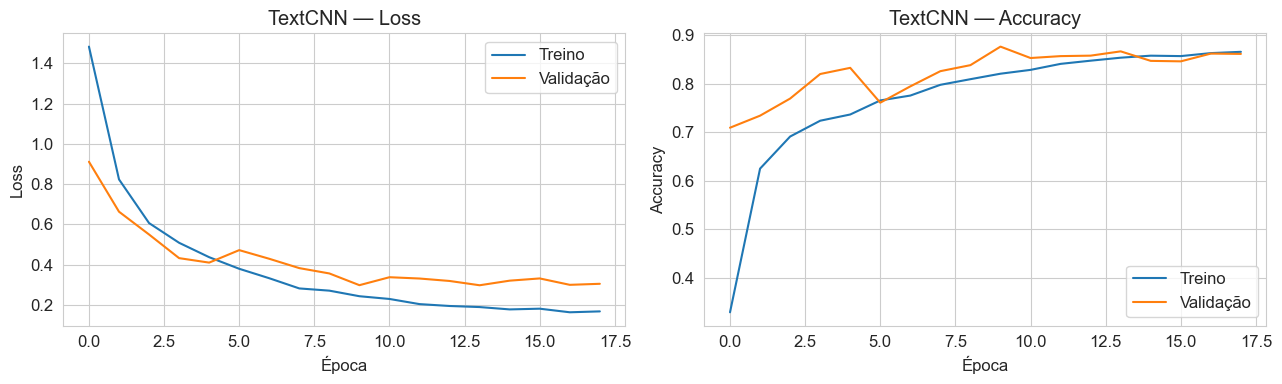

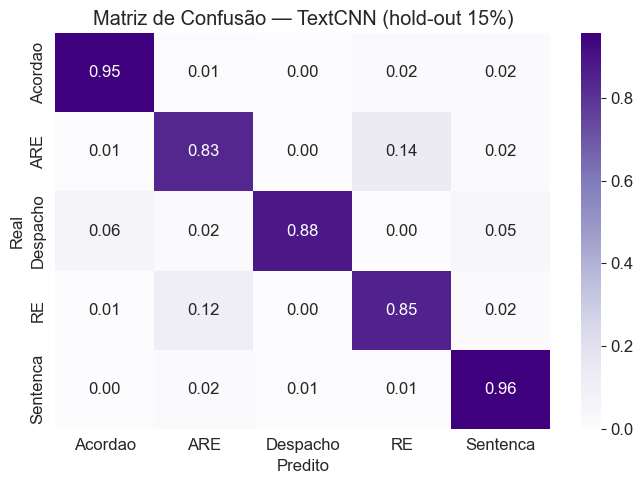

  TextCNN (W2V embeddings)             F1-macro=0.8572  F1-weighted=0.8709  acc=0.8668

Relatório de classificação — TextCNN (W2V embeddings) (hold-out):
              precision    recall  f1-score   support

     Acordao       0.82      0.95      0.88       100
         ARE       0.65      0.83      0.73       529
    Despacho       0.84      0.88      0.86        66
          RE       0.95      0.85      0.90      1932
    Sentenca       0.89      0.96      0.92       435

    accuracy                           0.87      3062
   macro avg       0.83      0.89      0.86      3062
weighted avg       0.88      0.87      0.87      3062



In [56]:
exp.plotar_historico(hist_cnn, 'TextCNN')
exp.plotar_matriz_confusao_nn('TextCNN', cnn_model, X_val_nn, y_val_nn, cmap='Purples')
resultado_cnn = exp.avaliar_modelo_nn('TextCNN (W2V embeddings)', cnn_model, X_val_nn, y_val_nn)


COMPARATIVO — MODELOS PROFUNDOS (hold-out 15%)


,F1-Macro (media),F1-Weighted (media),Acuracia (media)
Modelo,,,
BiLSTM (W2V embeddings),0.7791,0.7989,0.7900
TextCNN (W2V embeddings),0.8572,0.8709,0.8668


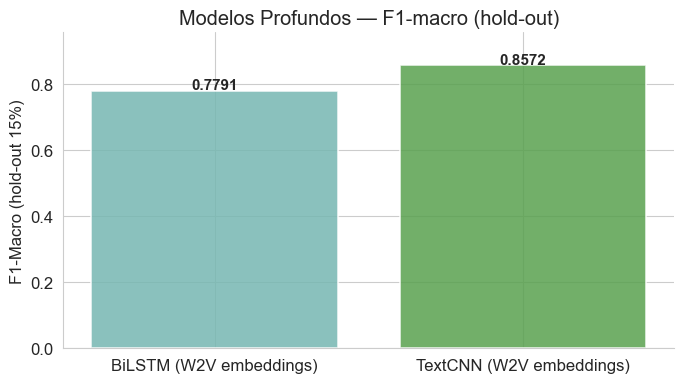


Salvando modelos profundos...
✅ Modelos BiLSTM, CNN e vocabulário salvos com sucesso em: /kaggle/working/dados/modelos_profundos


In [ ]:
import os
import pickle

resultados_profundos, display_profundos = exp.tabela_comparativa_profundos(
    [resultado_bilstm, resultado_cnn]
)
display(display_profundos)

exp.plotar_comparativo_profundos(resultados_profundos)

print("\nSalvando modelos profundos...")

if os.path.exists('/kaggle/working'):
    nn_dir = '/kaggle/working/dados/modelos_profundos'
else:
    nn_dir = '../dados/modelos_profundos'

os.makedirs(nn_dir, exist_ok=True)

bilstm_model.save(os.path.join(nn_dir, 'bilstm.keras'))
cnn_model.save(os.path.join(nn_dir, 'textcnn.keras'))

with open(os.path.join(nn_dir, 'word2idx.pkl'), 'wb') as f:
    pickle.dump(word2idx, f)

print(f"✅ Modelos BiLSTM, CNN e vocabulário salvos com sucesso em: {nn_dir}")

#### 3.3.7 Análise dos Modelos Profundos

**BiLSTM** captura dependências bidirecionais de longo alcance, o que é relevante
para o domínio jurídico, onde o significado de um trecho depende do contexto anterior
e posterior (ex.: *negar provimento*, *dar parcial provimento*).  
O segundo nível de BiLSTM (`return_sequences=True` → `LSTM`) cria uma representação
hierárquica da sequência antes da classificação.

**TextCNN** aplica filtros de 2–5 tokens em paralelo — equivalente a capturar bigramas,
trigramas, 4-gramas e 5-gramas simultaneamente. O `GlobalMaxPool1D` seleciona a
feature mais ativada em toda a sequência, tornando o modelo invariante à posição.  
Costuma convergir mais rapidamente do que o BiLSTM e ser competitivo em tarefas de
categorização onde a posição dos termos importa menos do que a sua co-ocorrência.

**Pontos de atenção:**
- Ambos os modelos usam embeddings W2V fixos (`trainable=False`) para evitar
  overfitting em classes minoritárias (Acórdão, Despacho). Liberar o treinamento
  (`trainable=True`) pode melhorar o resultado, mas exige mais épocas e regularização.
- `SpatialDropout1D` dropa dimensões inteiras do embedding, sendo mais eficaz
  do que o Dropout convencional para dados sequenciais.

### 3.4 Adaptação de Modelos de Linguagem — BERTimbau (Fine-tuning e PEFT/LoRA)

Modelos baseados em Transformers pré-treinados em grandes corpora em português
representam o estado da arte em categorização de texto jurídico.  
Nesta seção exploramos duas estratégias de adaptação:

| Estratégia | Parâmetros ajustados | Custo computacional |
|------------|---------------------|--------------------|
| **Full Fine-tuning** | Todos os parâmetros do modelo | Alto (GPU recomendada) |
| **PEFT/LoRA** | Apenas matrizes de baixo-rank (~0,5% dos params) | Baixo (roda em CPU/GPU pequena) |

**Modelo base:** `neuralmind/bert-base-portuguese-cased` (BERTimbau), pré-treinado
em ~2,7 GB de texto em português (Wikipedia PT + BrWaC).

> **Nota de reprodutibilidade:** os checkpoints gerados nesta seção são salvos em
> `../dados/modelos_transformers/`. Para re-executar sem retreinar, basta carregar
> o checkpoint salvo e pular as células de treinamento.

In [ ]:
DEVICE = exp.detectar_device()

Note: you may need to restart the kernel to use updated packages.
Dispositivo : cpu



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
tok_ds, tokenizer, data_collator, df_tr, df_val = exp.preparar_datasets_bert()

Tokenizando: 100%|██████████| 2521/2521 [00:01<00:00, 2197.99 examples/s]

Splits tokenizados:
  train : 17,350 exemplos | colunas: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
  val   : 3,062 exemplos | colunas: ['label', 'input_ids', 'token_type_ids', 'attention_mask']
  test  : 2,521 exemplos | colunas: ['input_ids', 'token_type_ids', 'attention_mask']


In [60]:
print('Função de métricas e DataCollator prontos via exp.compute_metrics_bert.')

Função de métricas e DataCollator prontos via exp.compute_metrics_bert.


#### 3.4.3 PEFT/LoRA — Adaptação de Baixo Custo

LoRA (Hu et al., 2021) injeta matrizes de baixo rank (A e B, onde rank ≪ d_model)
nas camadas de atenção do BERT. Apenas essas matrizes são atualizadas durante o
treinamento — o modelo base permanece congelado.

Isso reduz o número de parâmetros treináveis de ~109M (full fine-tuning) para
~500K–2M (LoRA), viabilizando o treinamento em CPUs ou GPUs com pouca VRAM.

In [ ]:
from pathlib import Path
import os

print("Redirecionando diretórios de salvamento...")

if os.path.exists('/kaggle/working'):
    pasta_transformers = '/kaggle/working/dados/modelos_transformers'
else:
    pasta_transformers = '../dados/modelos_transformers'

exp.TRANS_DIR = Path(pasta_transformers)

exp.TRANS_DIR.mkdir(parents=True, exist_ok=True)

print("Iniciando o treinamento do modelo LoRA (isso pode levar alguns minutos)...")

trainer_lora, lora_model = exp.treinar_lora(
    tok_ds, tokenizer, data_collator,
    class_weights_nn, DEVICE,
    bert_batch=32,
    max_train_samples=2000,
)

print(f"✅ Treinamento concluído e salvo em: {exp.TRANS_DIR}")

Redirecionando diretórios de salvamento...
Iniciando o treinamento do modelo LoRA (isso pode levar alguns minutos)...
Usando subset de treino: 2,000 exemplos (de 17,350 originais)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11419.24it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 593,669 || all params: 109,520,650 || trainable%: 0.5421
Iniciando treinamento LoRA...


In [ ]:
resultado_lora = exp.avaliar_transformer(
    'BERTimbau + LoRA', trainer_lora, tok_ds, df_val, cmap='Oranges'
)

In [ ]:
exp.salvar_lora(lora_model, tokenizer)

#### 3.4.4 Full Fine-tuning do BERTimbau

No fine-tuning completo todos os parâmetros do modelo são atualizados.  
Tipicamente produz resultados superiores ao LoRA, mas requer GPU com ≥8 GB de VRAM.

> **Se não houver GPU disponível**, esta célula é pulada automaticamente e o
> resultado do LoRA é usado como representante dos Transformers.

In [ ]:
trainer_ft = exp.treinar_finetuning_completo(
    tok_ds, tokenizer, data_collator,
    class_weights_nn, DEVICE,
    bert_batch=32,
    max_train_samples=2000,
)

if trainer_ft is not None:
    resultado_bert_ft = exp.avaliar_transformer(
        'BERTimbau Full Fine-tuning', trainer_ft, tok_ds, df_val, cmap='Greens'
    )
else:
    resultado_bert_ft = resultado_lora.copy()
    resultado_bert_ft['Modelo'] = 'BERTimbau + LoRA (sem GPU)'
    print('Usando resultado LoRA como representante dos Transformers.')

In [ ]:
resultados_transformers, display_transformers = exp.tabela_comparativa_transformers(
    [resultado_lora, resultado_bert_ft]
)
display(display_transformers)

#### 3.4.6 Análise dos Modelos Transformers

**PEFT/LoRA** é a abordagem recomendada quando há restrições de hardware:
ajusta apenas ~0,5% dos parâmetros do BERTimbau, mas mantém a rica representação
contextual pré-treinada em português. O hiperparâmetro `r` (rank) controla a
capacidade de adaptação — valores maiores capturam mais variações, mas aumentam
o custo computacional.

**Full Fine-tuning** libera todos os parâmetros, permitindo que o modelo se adapte
completamente ao vocabulário e ao estilo do STF. A taxa de aprendizado baixíssima
(2e-5) evita o *catastrophic forgetting* do conhecimento pré-treinado.

**WeightedTrainer:** a Cross-Entropy com pesos de classe é fundamental aqui, pois
o Transformer, sem essa penalização, tenderia a predizer quase exclusivamente a
classe majoritária (RE) nas épocas iniciais.

### 3.5 Geração do Arquivo de Submissão Final

Esta seção reúne todos os modelos treinados, seleciona as **duas melhores soluções**
conforme exigido pelo projeto, e gera os arquivos `submission_*.csv` para envio ao Kaggle.

O pipeline é:
1. Consolida todos os resultados (clássicos + profundos + Transformers);
2. Identifica os dois melhores modelos por F1-macro;
3. Re-treina cada um no conjunto de treino completo (sem hold-out);
4. Gera as predições no `test.csv` e salva no formato exigido.

In [ ]:
todos_resultados = exp.consolidar_resultados()
display(todos_resultados.sort_values('F1-Macro (media)', ascending=False))

In [ ]:
ranking = exp.plotar_ranking_geral(todos_resultados)

print('\nDuas melhores soluções selecionadas para submissão:')
display(ranking.head(2))

In [ ]:
sub1 = exp.gerar_submissao_final(
    'submission_final_1.csv', ranking, posicao=0,
    X_test_tfidf=X_test_tfidf,
    ids_teste=test_completo['Id'].values,
    bilstm_model=bilstm_model, cnn_model=cnn_model,
    X_seq_test=X_seq_test,
    trainer_lora=trainer_lora, tok_ds=tok_ds,
)

In [ ]:
sub2 = exp.gerar_submissao_final(
    'submission_final_2.csv', ranking, posicao=1,
    X_test_tfidf=X_test_tfidf,
    ids_teste=test_completo['Id'].values,
    bilstm_model=bilstm_model, cnn_model=cnn_model,
    X_seq_test=X_seq_test,
    trainer_lora=trainer_lora, tok_ds=tok_ds,
)

In [ ]:
exp.validar_submissao('submission_final_1.csv', sub1)
exp.validar_submissao('submission_final_2.csv', sub2)

In [ ]:
ranking_final = exp.exibir_resumo_final(
    ranking,
    ['submission_final_1.csv', 'submission_final_2.csv'],
)
display(ranking_final)

#### 3.5.7 Estratégia das Duas Soluções Finais

Conforme a seção **Estratégia Final** do relatório exigida pelo projeto, as duas
submissões ao Kaggle correspondem aos dois melhores modelos por F1-macro no
conjunto de validação (hold-out estratificado de 15%).

**Critério de seleção:**
- F1-macro foi escolhido como métrica principal por ser robusto ao severo
  desbalanceamento de classes (RE domina ~60% do corpus);
- Modelos que obtiveram F1 alto para as classes majoritárias mas baixo para
  Acórdão (0) e Despacho (2) foram penalizados naturalmente pelo F1-macro.

**Reprodutibilidade:**
- Todos os modelos foram treinados com `random_state=42`;
- As matrizes TF-IDF e os embeddings W2V foram fixados antes do split de validação
  para evitar data leakage;
- Os modelos Keras e os adaptadores LoRA foram salvos em disco e podem ser
  recarregados sem re-treinamento.

